In [3]:
!pip install transformers datasets peft accelerate bitsandbytes
!pip install torchvision pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00


In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
from datasets import load_dataset

dataset = load_dataset("rootsautomation/RICO-Screen2Words")
dataset


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/216M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/225M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

...

data/test-00001-of-00002.parquet:   0%|          | 0.00/244M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15743 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/2364 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4310 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['screenId', 'captions', 'file_name', 'app_package_name', 'play_store_name', 'category', 'average_rating', 'number_of_ratings', 'number_of_downloads', 'file_name_icon', 'file_name_semantic', 'semantic_annotations', 'view_hierarchy', 'image', 'image_icon', 'image_semantic'],
        num_rows: 15743
    })
    val: Dataset({
        features: ['screenId', 'captions', 'file_name', 'app_package_name', 'play_store_name', 'category', 'average_rating', 'number_of_ratings', 'number_of_downloads', 'file_name_icon', 'file_name_semantic', 'semantic_annotations', 'view_hierarchy', 'image', 'image_icon', 'image_semantic'],
        num_rows: 2364
    })
    test: Dataset({
        features: ['screenId', 'captions', 'file_name', 'app_package_name', 'play_store_name', 'category', 'average_rating', 'number_of_ratings', 'number_of_downloads', 'file_name_icon', 'file_name_semantic', 'semantic_annotations', 'view_hierarchy', 'image', 'image_icon', 'imag

In [6]:
small_dataset = dataset["train"].shuffle(seed=42).select(range(2000))

In [7]:
from transformers import BlipProcessor, BlipForConditionalGeneration

model_name = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [8]:
def preprocess(example):

    caption = example["captions"]

    # captions sometimes come as a list → convert to string
    if isinstance(caption, list):
        caption = caption[0]

    inputs = processor(
        images=example["image"],
        text=caption,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    inputs["labels"] = inputs["input_ids"]

    # remove batch dimension
    inputs = {k: v.squeeze() for k, v in inputs.items()}

    return inputs


processed_dataset = small_dataset.map(
    preprocess,
    remove_columns=small_dataset.column_names
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [9]:
print(small_dataset[0]["captions"])
print(type(small_dataset[0]["captions"]))

['display shows different options', 'display of a page showing timer app', 'page displaying about the start and end time of schedule', 'page displaying start time and end time to save schedule', 'screen displaying different controls to prepare a schedule']
<class 'list'>


In [10]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],   # correct modules for BLIP
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 589,824 || all params: 248,034,424 || trainable%: 0.2378


In [11]:
print(small_dataset[0]["captions"])
print(type(small_dataset[0]["captions"]))

['display shows different options', 'display of a page showing timer app', 'page displaying about the start and end time of schedule', 'page displaying start time and end time to save schedule', 'screen displaying different controls to prepare a schedule']
<class 'list'>


In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset,
)

trainer.train()

Step,Training Loss
10,13.072528
20,11.985200
30,10.254256
40,9.646550
50,9.199226
60,8.856624
70,8.611842
80,8.434718
90,8.330530
100,8.252657


TrainOutput(global_step=500, training_loss=8.296366821289062, metrics={'train_runtime': 694.4888, 'train_samples_per_second': 2.88, 'train_steps_per_second': 0.72, 'total_flos': 1.190140369698816e+18, 'train_loss': 8.296366821289062, 'epoch': 1.0})

In [13]:
model.save_pretrained("rico-blip-lora")
processor.save_pretrained("rico-blip-lora")

['rico-blip-lora/processor_config.json']

In [14]:
model.push_to_hub("rico-ui-captioner")
processor.push_to_hub("rico-ui-captioner")


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  24%|##3       |  569kB / 2.37MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/surabhimuralidhar/rico-ui-captioner/commit/8900c655bacf2a58f2c36efed304807d786cb443', commit_message='Upload processor', commit_description='', oid='8900c655bacf2a58f2c36efed304807d786cb443', pr_url=None, repo_url=RepoUrl('https://huggingface.co/surabhimuralidhar/rico-ui-captioner', endpoint='https://huggingface.co', repo_type='model', repo_id='surabhimuralidhar/rico-ui-captioner'), pr_revision=None, pr_num=None)

In [15]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
from io import BytesIO

model = BlipForConditionalGeneration.from_pretrained("surabhimuralidhar/rico-ui-captioner")
processor = BlipProcessor.from_pretrained("surabhimuralidhar/rico-ui-captioner")

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"

image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print("Generated Caption:", caption)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

adapter_model.safetensors:   0%|          | 0.00/2.37M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: surabhimuralidhar/rico-ui-captioner
Key                                                                                                       | Status     | 
----------------------------------------------------------------------------------------------------------+------------+-
base_model.model.text_decoder.bert.encoder.layer.{0...11}.attention.self.query.lora_A.default.weight      | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.crossattention.self.query.lora_B.default.weight | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.attention.self.query.lora_B.default.weight      | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.attention.self.value.lora_A.default.weight      | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.crossattention.self.query.lora_A.default.weight | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.atten

Generated Caption: two cats sleeping on a couch


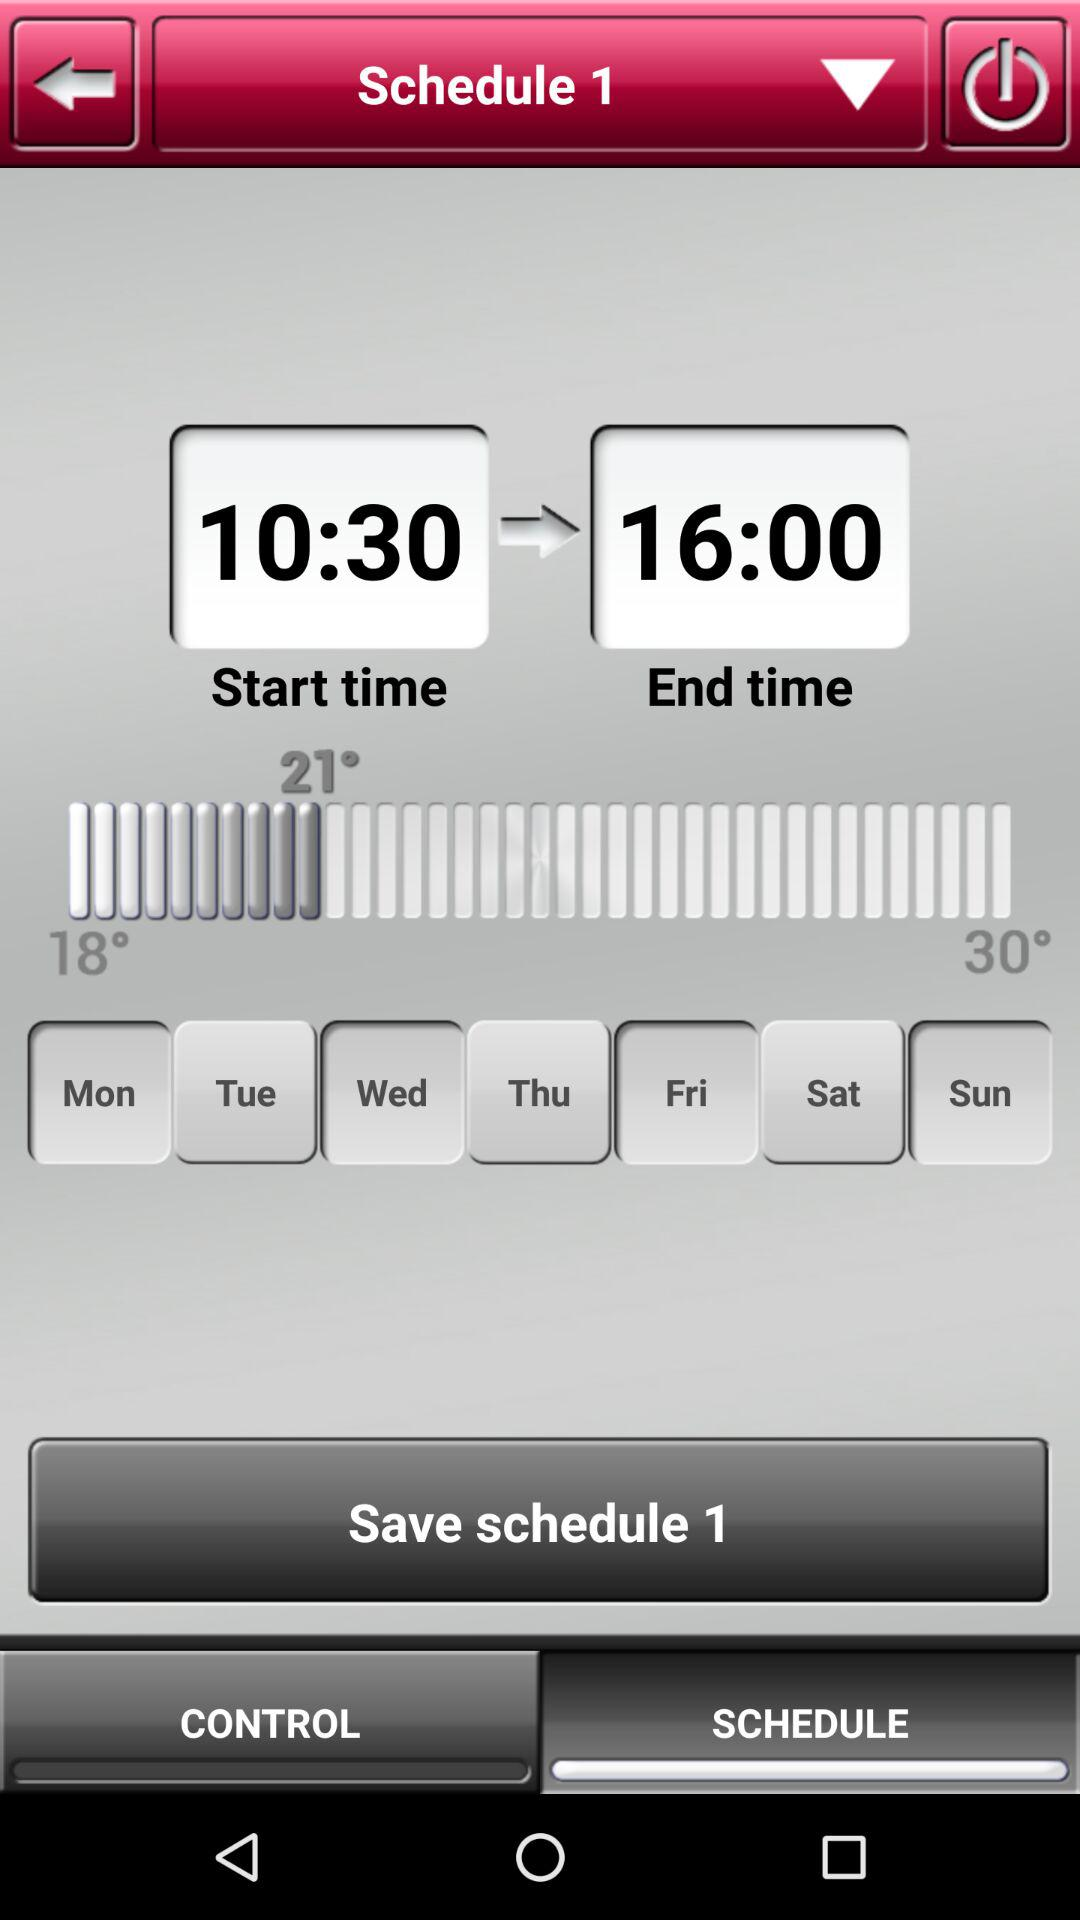

Actual Caption: ['display shows different options', 'display of a page showing timer app', 'page displaying about the start and end time of schedule', 'page displaying start time and end time to save schedule', 'screen displaying different controls to prepare a schedule']


In [16]:
from IPython.display import display

display(small_dataset[0]["image"])
print("Actual Caption:", small_dataset[0]["captions"])

In [17]:
image = small_dataset[0]["image"]

inputs = processor(images=image, return_tensors="pt")

output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print("Generated Caption:", caption)

Generated Caption: a clock with the time displayed on it


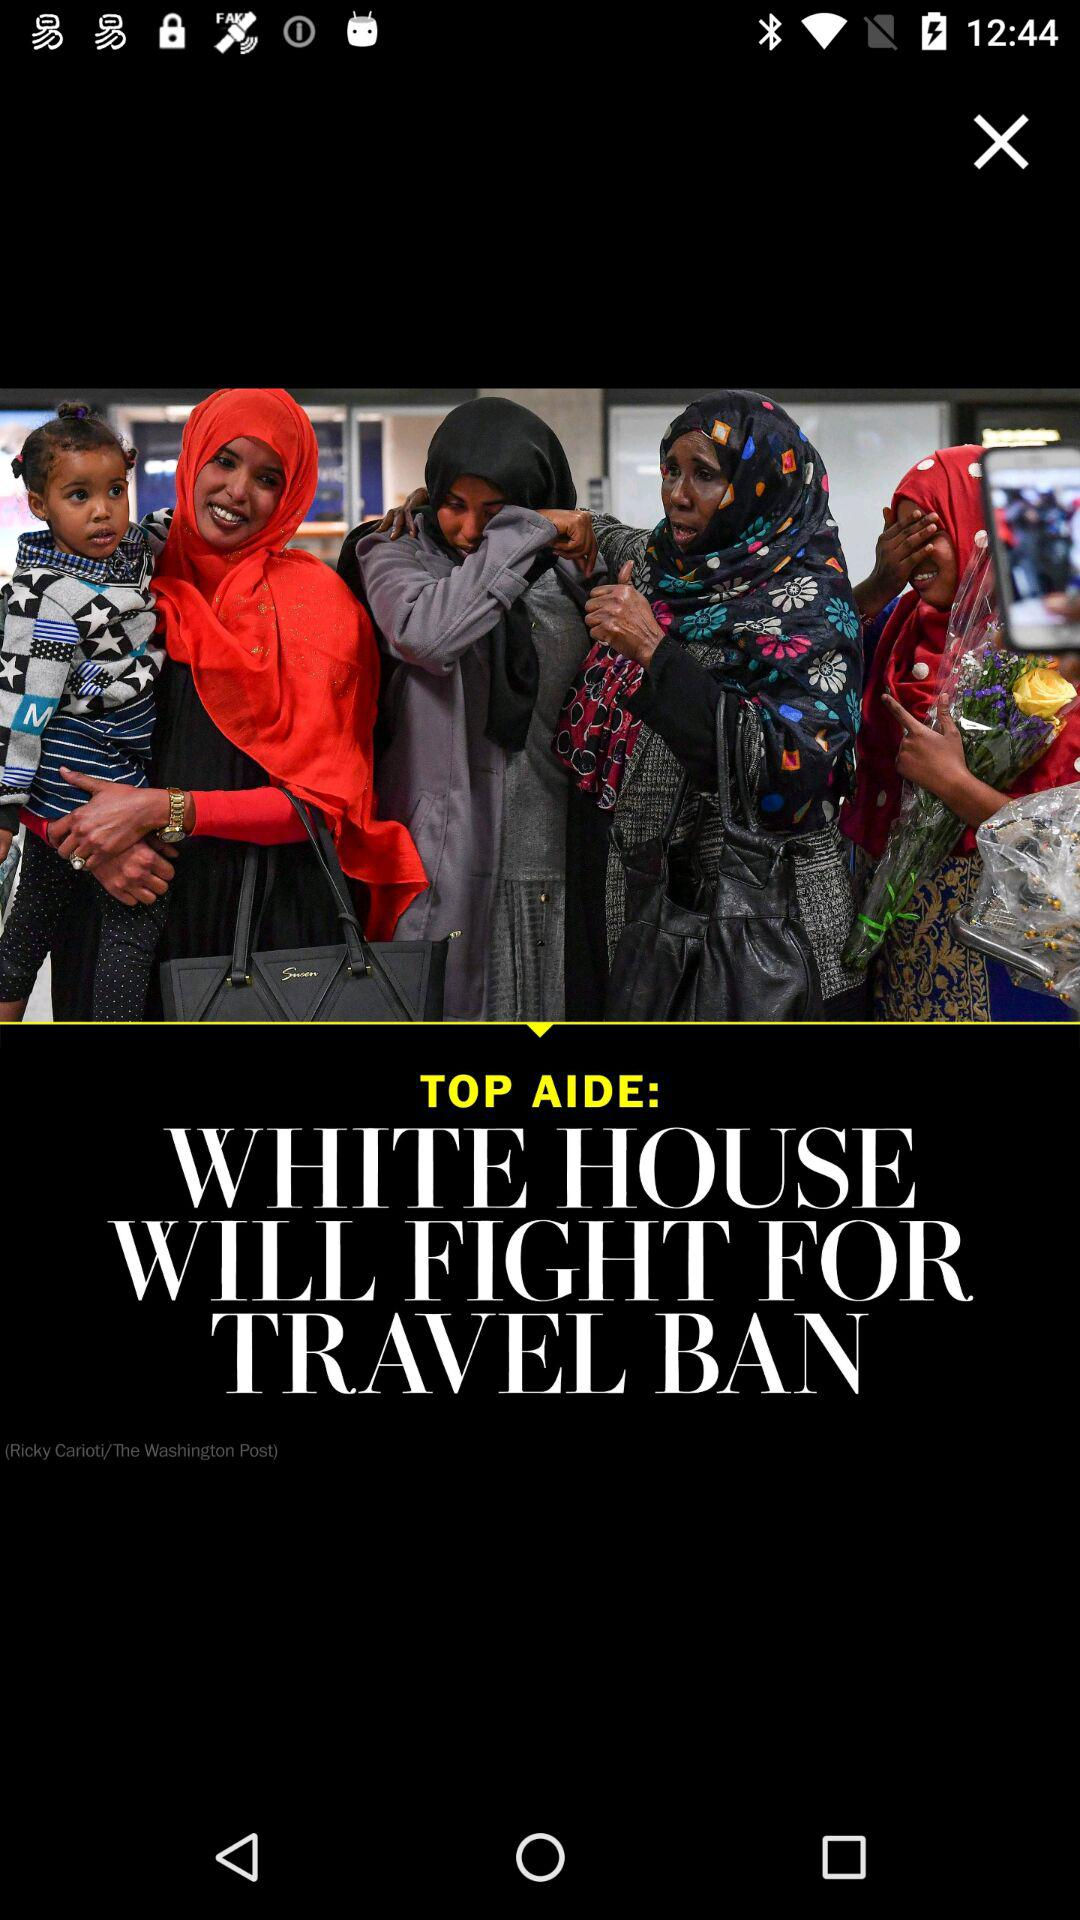

Ground Truth: ['page displaying a news in a news app', 'page displaying article in news application', 'page displaying top aide in a news app', 'page showing a image with some text in news app', 'screen showing post /news']
Model Prediction: the white house traveler app on the iphone


In [18]:
from IPython.display import display

sample = small_dataset[5]

display(sample["image"])

print("Ground Truth:", sample["captions"])

inputs = processor(images=sample["image"], return_tensors="pt")

output = model.generate(**inputs)

pred = processor.decode(output[0], skip_special_tokens=True)

print("Model Prediction:", pred)

In [19]:
from peft import PeftModel

base_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = PeftModel.from_pretrained(
    base_model,
    "surabhimuralidhar/rico-ui-captioner"
)

# merge LoRA weights
model = model.merge_and_unload()

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [20]:
model.save_pretrained("rico-final-model")
processor.save_pretrained("rico-final-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['rico-final-model/processor_config.json']

In [21]:
model.push_to_hub("rico-ui-captioner-final")
processor.push_to_hub("rico-ui-captioner-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...qcvb9tj/model.safetensors:   2%|2         | 23.4MB /  990MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/surabhimuralidhar/rico-ui-captioner-final/commit/e00b0f132a59a04921c645dad3afcde9d29b581d', commit_message='Upload processor', commit_description='', oid='e00b0f132a59a04921c645dad3afcde9d29b581d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/surabhimuralidhar/rico-ui-captioner-final', endpoint='https://huggingface.co', repo_type='model', repo_id='surabhimuralidhar/rico-ui-captioner-final'), pr_revision=None, pr_num=None)

In [22]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
from io import BytesIO

# Hugging Face model repo
MODEL_ID = "surabhimuralidhar/rico-ui-captioner-final"

print("Loading model from Hugging Face...")

# Load model and processor
model = BlipForConditionalGeneration.from_pretrained(MODEL_ID)
processor = BlipProcessor.from_pretrained(MODEL_ID)

print("Model loaded successfully!")

# Sample image for testing
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"

print("Downloading sample image...")

image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# Preprocess image
inputs = processor(images=image, return_tensors="pt")

print("Running inference...")

# Generate caption
output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print("\nGenerated Caption:")
print(caption)

Loading model from Hugging Face...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded successfully!
Running inference...

Generated Caption:
two cats laying on a couch
